In [76]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

In [77]:
df=pd.read_csv('Bengaluru_House_Datastudent.csv-1.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [79]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [80]:
df=df.drop(["area_type","availability","society","balcony"],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [81]:
df['location'].value_counts()
df['location']=df['location'].fillna('Sarjapur Road')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [82]:
df['size'].value_counts()
df['size']=df['size'].fillna('2 BHK')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [83]:
df['bath'] = df['bath'].fillna(df['bath'].median())
df.info

<bound method DataFrame.info of                        location       size total_sqft  bath   price
0      Electronic City Phase II      2 BHK       1056   2.0   39.07
1              Chikka Tirupathi  4 Bedroom       2600   5.0  120.00
2                   Uttarahalli      3 BHK       1440   2.0   62.00
3            Lingadheeranahalli      3 BHK       1521   3.0   95.00
4                      Kothanur      2 BHK       1200   2.0   51.00
...                         ...        ...        ...   ...     ...
13315                Whitefield  5 Bedroom       3453   4.0  231.00
13316             Richards Town      4 BHK       3600   5.0  400.00
13317     Raja Rajeshwari Nagar      2 BHK       1141   2.0   60.00
13318           Padmanabhanagar      4 BHK       4689   4.0  488.00
13319              Doddathoguru      1 BHK        550   1.0   17.00

[13320 rows x 5 columns]>

In [84]:
df['size'].unique()
out = [int(i.split()[0]) for i in df['size']]
df['bhk'] = out
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
 5   bhk         13320 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 624.5+ KB


In [85]:
df[df['bhk']>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [86]:
df['total_sqft'].unique()
def convert(a):
    l = a.split('-')
    if len(l) == 2:
        return (float(l[0]) + float(l[1])) / 2
    try:
        return float(a)
    except:
        return None
df['total_sqft'] = df['total_sqft'].apply(convert)

In [88]:
df['price_par_sqft']=df['price']*100000/df['total_sqft']
df['price_par_sqft']

0         3699.810606
1         4615.384615
2         4305.555556
3         6245.890861
4         4250.000000
             ...     
13315     6689.834926
13316    11111.111111
13317     5258.545136
13318    10407.336319
13319     3090.909091
Name: price_par_sqft, Length: 13320, dtype: float64

In [89]:
df['location'] = df['location'].apply(lambda x: x.strip())


location_counts = df['location'].value_counts()


loc_lessthan_10 = location_counts[location_counts <= 10]

print(loc_lessthan_10)

location
BTM 1st Stage                         10
Nagadevanahalli                       10
Basapura                              10
Sector 1 HSR Layout                   10
Dairy Circle                          10
                                      ..
1Channasandra                          1
Hosahalli                              1
Vijayabank bank layout                 1
near Ramanashree California resort     1
Abshot Layout                          1
Name: count, Length: 1054, dtype: int64


In [90]:
df['location']=df['location'].apply(lambda x: 'other' if x in loc_lessthan_10 else x)

In [91]:
df['location'].value_counts()

location
other                 2886
Whitefield             541
Sarjapur  Road         399
Electronic City        304
Kanakpura Road         273
                      ... 
Nehru Nagar             11
Banjara Layout          11
LB Shastri Nagar        11
Pattandur Agrahara      11
Narayanapura            11
Name: count, Length: 242, dtype: int64

In [92]:
df.describe()

,total_sqft,bath,price,bhk,price_par_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [93]:
(df['total_sqft']/df['bhk']).describe()

count    13274.000000
mean       575.074878
std        388.205175
min          0.250000
25%        473.333333
50%        552.500000
75%        625.000000
max      26136.000000
dtype: float64

In [94]:
df=df[(df['total_sqft']/df['bhk'])>=300]
df.describe()

,total_sqft,bath,price,bhk,price_par_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [39]:
df = df[df['total_sqft'] >= df['bhk'] * 300]
df.describe()

,total_sqft,bath,price,bhk,price_par_sqft
count,12514.000000,12514.000000,12514.000000,12514.000000,12514.000000
mean,1593.746383,2.560253,111.398333,2.651670,6307.367132
std,1261.351669,1.078441,152.098807,0.977025,4160.773691
min,300.000000,1.000000,9.000000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.762120
50%,1300.000000,2.000000,70.000000,3.000000,5295.073227
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


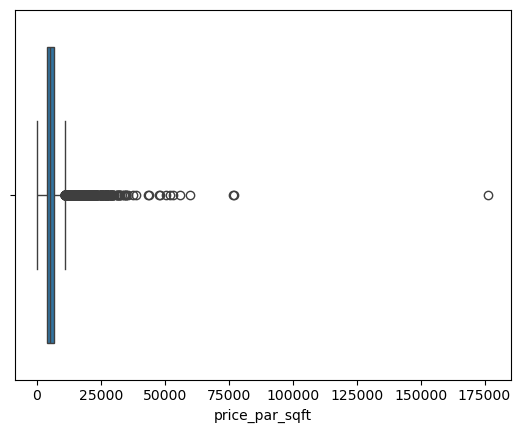

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='price_par_sqft', data=df)
plt.show()

In [97]:
q1=df['price_par_sqft'].quantile(0.25)
q3=df['price_par_sqft'].quantile(0.75)
IQR=q3-q1
lower_bound=q1-0.5*IQR
upper_bound=q3+0.5*IQR
df=df[(df['price_par_sqft']>=lower_bound)&(df['price_par_sqft']<=upper_bound)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10350 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        10350 non-null  object 
 1   size            10350 non-null  object 
 2   total_sqft      10350 non-null  float64
 3   bath            10350 non-null  float64
 4   price           10350 non-null  float64
 5   bhk             10350 non-null  int64  
 6   price_par_sqft  10350 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 646.9+ KB


<Axes: xlabel='price_par_sqft'>

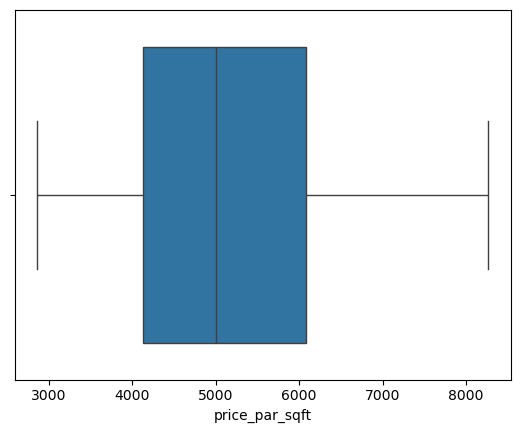

In [99]:
sns.boxplot(x='price_par_sqft',data=df)

In [100]:
df=df[df['bhk']<=6]

In [101]:
df=df[df['bath']<df['bhk']+2]

In [102]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_par_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [104]:
df = df.drop(['size', 'price_par_sqft'], axis=1)
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


In [105]:
df.reset_index(inplace=True)
df=df.drop('index',axis=1)

In [106]:
cleaned=df.copy()

In [107]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['location']= encoder.fit_transform(df[['location']])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [108]:
X=df.drop('price',axis=1)
y=df['price']

In [117]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [118]:
model=RandomForestRegressor (random_state=42)
params={
    "n_estimators":[100,150,200,250,300],
    "max_depth":[3,4,5,6]
}



grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'n_estimators': [100, 150, 200, 250, 300]})

In [119]:
print("Best params:",grid.best_params_)
print("best score:",grid.best_score_)

Best params: {'max_depth': 6, 'n_estimators': 300}
best score: 0.8395463166204997


In [120]:
print('Training Eff:',grid.score(X_train,y_train))
print('Testing Eff:',grid.score(X_test,y_test))

Training Eff: 0.8917382645794697
Testing Eff: 0.8362095113923503


In [121]:
ypred=grid.predict(X_test)

In [122]:
print('R2:',r2_score(y_test,ypred))

R2: 0.8362095113923503


In [123]:
print('MAE:',mean_absolute_error(y_test,ypred))

MAE: 14.179111992523515


In [124]:
with open('RFmodel.pkl','wb')as file:
    pickle.dump(grid,file)

In [125]:
df.head()

,location,total_sqft,bath,price,bhk
0,78,1056.0,2.0,39.07,2
1,60,2600.0,5.0,120.00,4
2,225,1440.0,2.0,62.00,3
3,158,1521.0,3.0,95.00,3
4,150,1200.0,2.0,51.00,2


In [126]:
cleaned['encoded_loc']=df['location']

In [127]:
df.describe()

,location,total_sqft,bath,price,bhk
count,10230.000000,10230.00000,10230.000000,10230.000000,10230.000000
mean,151.842717,1432.13379,2.367937,76.218467,2.495992
std,76.392610,773.66501,0.779985,54.319457,0.753740
min,0.000000,300.00000,1.000000,10.000000,1.000000
25%,92.000000,1100.00000,2.000000,47.000000,2.000000
50%,160.000000,1256.50000,2.000000,64.000000,2.000000
75%,234.000000,1577.00000,3.000000,89.112500,3.000000
max,240.000000,30400.00000,7.000000,2100.000000,6.000000


In [128]:
df.bath.unique()

array([2., 5., 3., 4., 1., 6., 7.])

In [129]:
df.shape

(10230, 5)

In [130]:
df.sample(5)

,location,total_sqft,bath,price,bhk
5460,240,900.0,2.0,65.0,3
9190,113,1520.0,3.0,125.0,3
4896,240,1250.0,2.0,58.0,2
9553,234,1200.0,2.0,70.0,2
7149,240,1108.0,2.0,48.0,2
